# FlashEats — Class 5 Investigation

## Client escalation

> **“Late deliveries are increasing and customers say our ETA is unreliable. Figure out what is happening before we invest in an AI delay-prediction system.”**

Today is not a syntax lesson. Your job is to use SQL, CSV, JSON and APIs like an FDE:

**define the question → retrieve evidence → validate completeness → reconcile sources → state what you know and what you still cannot know**

### Rules
- Do not train an ML model.
- State your definition of **late** before calculating it.
- Preserve raw API responses.
- Do not silently drop failures.
- If another team gets a different answer, investigate the definition and data grain first.

In [1]:
# 0. INSTALLS + IMPORTS
!pip -q install pandas requests flask matplotlib

import os, sys, json, time, sqlite3, subprocess, zipfile
from pathlib import Path

import pandas as pd
import requests
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

print("Environment ready.")


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Environment ready.


In [2]:
# Locally this notebook sits next to database/ and data/, so use that folder.
BASE = Path.cwd() if (Path.cwd() / "database" / "flasheats.db").exists() else None

if BASE is None:
    BASE = Path("/content/FlashEats_Classroom_Pack")
    if not BASE.exists():
        try:
            from google.colab import files
            print("Upload FlashEats_Classroom_Pack.zip")
            uploaded = files.upload()
            zip_name = next(name for name in uploaded if name.endswith(".zip"))
            with zipfile.ZipFile(zip_name, "r") as z:
                z.extractall("/content")
        except Exception as e:
            print("If running locally, set BASE manually to the extracted pack.")
            print(e)

print("BASE:", BASE)
print("Exists:", (BASE / "database" / "flasheats.db").exists())

BASE: C:\Users\Asus\Documents\3rd year\term 1\FDE-Manan-Gupta\nyc-tlc-cbd-pipeline\class_notebooks\flasheats
Exists: True


## 2. Source map first

Before analysis, predict where you would look for:

| Information | Likely source | Why? |
|---|---|---|
| Promised delivery time |  |  |
| Actual delivery time |  |  |
| Driver assignment |  |  |
| Customer complaint |  |  |
| Restaurant status |  |  |
| Driver movement/events |  |  |

**Discuss:** Which source is authoritative for each fact, and which is only contextual?

### My source map

| Information | Likely source | Why? |
|---|---|---|
| Promised delivery time | `orders.promised_eta` (SQLite) | The order platform makes the promise to the customer, so it owns this value |
| Actual delivery time | `orders.actual_delivery_at`, with `driver_events` `delivered` as a cross-check | The order record is the system of record, but the driver app is where delivery is actually captured |
| Driver assignment | Dispatch API (`assigned_at`, `reassigned_at`, `original_driver_id`) | Dispatch owns assignment. `orders.driver_id` only shows the final driver |
| Customer complaint | `support_tickets.csv` | Support system. Good for what customers experienced, not for timings |
| Restaurant status | `restaurant_status.csv` | Updated by restaurant staff (some manually), so treat it as context |
| Driver movement/events | `driver_events.json` | Driver app: assignment, GPS pings, pickup, delivery |

**Authoritative vs contextual:** the orders table and the Dispatch API are authoritative for the order lifecycle and
assignment. Driver events are authoritative for what the driver app recorded. Support tickets and restaurant status
are contextual: they explain delays but can't be used to time them.

In [3]:
# 3. BASIC SYNTAX — READ EVERY SOURCE

# SQLite
db_path = BASE / "database" / "flasheats.db"
con = sqlite3.connect(db_path)

tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    con
)
display(tables)

sample_orders = pd.read_sql("SELECT * FROM orders LIMIT 5;", con)
display(sample_orders)

# CSV
tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
restaurant_status = pd.read_csv(BASE / "data" / "restaurant_status.csv")
display(tickets.head())

# Nested JSON
with open(BASE / "data" / "driver_events.json", "r") as f:
    driver_events = json.load(f)

print("Driver objects:", len(driver_events))
display(driver_events[:1])

,name
0,customers
1,drivers
2,orders
3,restaurants


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,None,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


Driver objects: 120


[{'driver_id': 'D001',
  'events': [{'order_id': 'O00162',
    'type': 'assigned',
    'timestamp': '2026-08-26T17:53:25.977803'},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:10:59.372420',
    'lat': 12.826339,
    'lon': 77.448282},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:28:32.767037',
    'lat': 12.876013,
    'lon': 77.477707},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:46:06.161653',
    'lat': 12.925686,
    'lon': 77.507133},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T19:03:39.556270',
    'lat': 12.97536,
    'lon': 77.536558},
   {'order_id': 'O00162',
    'type': 'picked_up',
    'timestamp': '2026-08-26T18:27:32.131791'},
   {'order_id': 'O00162',
    'type': 'delivered',
    'timestamp': '2026-08-26T19:21:12.950887'},
   {'order_id': 'O00180',
    'type': 'assigned',
    'timestamp': '2026-08-08T18:05:08.439625'},
   {'o

# Challenge 1 — How large is the late-delivery problem?

Before coding, decide:

- **Late means:** ______________________________
- **Denominator:** _____________________________
- **Cancelled orders:** include / exclude / other?
- **Missing actual delivery timestamp:** what will you do?
- **Row grain:** what does one row represent?

### Required analysis
1. valid delivered orders,
2. late count and percentage,
3. median lateness among late orders,
4. worst delayed orders,
5. any data-quality issue that changes the metric.

### My definitions (written before calculating)

- **Late means:** delivered after `promised_eta` (delay > 0 min). I also report delay > 10 min, because a 1-minute miss is not what customers complain about.
- **Denominator:** delivered orders that have an actual delivery time, one row per `order_id`.
- **Cancelled orders:** excluded. They are not a delivery-speed outcome, so I report them separately.
- **Missing actual delivery timestamp:** excluded from the rate but counted and reported. A missing time is not the same as "on time".
- **Row grain:** one row should be one order, but I check this rather than assume it.

In [4]:
orders_raw = pd.read_sql("SELECT * FROM orders", con)
print("Rows:", len(orders_raw), "| unique order_id:", orders_raw["order_id"].nunique())

# The same order_id appears twice for 3 orders, and the copies disagree on traffic_bucket
dups = orders_raw[orders_raw["order_id"].duplicated(keep=False)].sort_values("order_id")
display(dups[["order_id", "final_status", "traffic_bucket", "promised_eta", "actual_delivery_at"]])

Rows: 1603 | unique order_id: 1600


,order_id,final_status,traffic_bucket,promised_eta,actual_delivery_at
119,O00120,delivered,severe,2026-08-13T19:40:24,2026-08-13T19:34:08.431508
1600,O00120,delivered,medium,2026-08-13T19:40:24,2026-08-13T19:34:08.431508
722,O00723,delivered,medium,2026-08-05T22:19:36,2026-08-05T22:04:30.928322
1601,O00723,delivered,high,2026-08-05T22:19:36,2026-08-05T22:04:30.928322
1301,O01302,delivered,medium,2026-08-26T22:15:50.273095,2026-08-26T22:20:27.428561
1602,O01302,delivered,high,2026-08-26T22:15:50.273095,2026-08-26T22:20:27.428561


In [5]:
orders = orders_raw.drop_duplicates("order_id", keep="first").copy()
for c in ["created_at", "promised_eta", "pickup_at", "actual_delivery_at"]:
    orders[c] = pd.to_datetime(orders[c], format="mixed", errors="coerce")

orders["status"] = orders["final_status"].str.strip().str.lower()
orders["traffic"] = orders["traffic_bucket"].str.strip().str.lower()
orders["delay_min"] = (orders["actual_delivery_at"] - orders["promised_eta"]).dt.total_seconds() / 60

print("final_status as stored:")
display(orders["final_status"].value_counts())
print("Delivered but no actual delivery time:", ((orders.status == "delivered") & orders.actual_delivery_at.isna()).sum())

delivered = orders[(orders.status == "delivered") & orders.actual_delivery_at.notna()].copy()
delivered["late"] = delivered["delay_min"] > 0

summary = pd.Series({
    "all orders (unique)": len(orders),
    "cancelled (excluded)": (orders.status == "cancelled").sum(),
    "delivered, missing actual time (excluded)": ((orders.status == "delivered") & orders.actual_delivery_at.isna()).sum(),
    "valid delivered orders": len(delivered),
    "late (> 0 min)": delivered.late.sum(),
    "late rate (> 0 min) %": round(100 * delivered.late.mean(), 1),
    "late rate (> 10 min) %": round(100 * (delivered.delay_min > 10).mean(), 1),
    "median lateness of late orders (min)": round(delivered.loc[delivered.late, "delay_min"].median(), 1),
})
summary

final_status as stored:


final_status
delivered    1527
cancelled      68
Delivered       5
Name: count, dtype: int64

Delivered but no actual delivery time: 37


all orders (unique)                          1600.0
cancelled (excluded)                           68.0
delivered, missing actual time (excluded)      37.0
valid delivered orders                       1495.0
late (> 0 min)                                843.0
late rate (> 0 min) %                          56.4
late rate (> 10 min) %                         23.3
median lateness of late orders (min)            8.0
dtype: float64

In [6]:
# Same headline number straight from SQL, to make sure pandas and SQL agree
sql = """
WITH one_row AS (
    SELECT * FROM orders
    WHERE rowid IN (SELECT MIN(rowid) FROM orders GROUP BY order_id)
)
SELECT
    COUNT(*) AS valid_delivered,
    SUM(CASE WHEN (julianday(actual_delivery_at) - julianday(promised_eta)) * 1440 > 0 THEN 1 ELSE 0 END) AS late_orders
FROM one_row
WHERE LOWER(TRIM(final_status)) = 'delivered' AND actual_delivery_at IS NOT NULL;
"""
check = pd.read_sql(sql, con)
check["late_pct"] = (100 * check.late_orders / check.valid_delivered).round(1)
check

,valid_delivered,late_orders,late_pct
0,1495,843,56.4


In [7]:
print("Worst delayed orders:")
display(delivered.nlargest(6, "delay_min")[["order_id", "restaurant_id", "driver_id", "traffic", "weather_bucket",
                                             "promised_eta", "actual_delivery_at", "delay_min"]].round(1))

# Data-quality checks that could change the metric
dq = pd.Series({
    "duplicate order rows": orders_raw["order_id"].duplicated().sum(),
    "'Delivered' with a capital D": (orders.final_status == "Delivered").sum(),
    "traffic stored as 'HIGH'": (orders.traffic_bucket == "HIGH").sum(),
    "delivered with no actual time": ((orders.status == "delivered") & orders.actual_delivery_at.isna()).sum(),
    "promised ETA before order created": (orders.promised_eta < orders.created_at).sum(),
    "delivered before picked up": (orders.actual_delivery_at < orders.pickup_at).sum(),
    "distance exactly 18.00 km": (orders.distance_km_estimate == 18.0).sum(),
    "missing restaurant_id or driver_id": (orders.restaurant_id.isna() | orders.driver_id.isna()).sum(),
})
display(dq)

# The top four "delays" are the orders whose promise is before they were even created
broken_eta = delivered.promised_eta < delivered.created_at
print("Worst delay excluding broken-ETA rows:", round(delivered.loc[~broken_eta, "delay_min"].max(), 1), "min")

Worst delayed orders:


,order_id,restaurant_id,driver_id,traffic,weather_bucket,promised_eta,actual_delivery_at,delay_min
103,O00104,R031,D055,medium,clear,2026-08-09 22:09:00.000000,2026-08-09 23:36:20.740161,87.3
101,O00102,R004,D056,medium,clear,2026-08-11 16:31:00.000000,2026-08-11 17:57:17.661772,86.3
100,O00101,R007,D111,low,rain,2026-08-24 20:49:00.000000,2026-08-24 22:14:30.685278,85.5
102,O00103,R020,D098,high,clear,2026-08-22 20:01:00.000000,2026-08-22 21:10:17.342305,69.3
1080,O01081,R048,D082,high,clear,2026-08-13 18:15:46.613098,2026-08-13 19:06:02.677891,50.3
472,O00473,R002,D064,high,clear,2026-08-14 20:17:48.000000,2026-08-14 21:04:00.769224,46.2


duplicate order rows                    3
'Delivered' with a capital D            5
traffic stored as 'HIGH'                3
delivered with no actual time          37
promised ETA before order created       4
delivered before picked up              5
distance exactly 18.00 km             806
missing restaurant_id or driver_id      6
dtype: int64

Worst delay excluding broken-ETA rows: 50.3 min


### Challenge 1 answer

- **Problem size:** of **1,495** valid delivered orders, **843 (56.4%)** arrived after the promised ETA. Only **23.3%**
  were more than 10 minutes late. The median late order was **8 minutes** late.
- **The "worst" orders are not real:** the four biggest delays (~86–87 min) are the four orders whose promised ETA is
  *before* the order was created, so their delay is a data error. The worst genuine delay is about 50 minutes.
- So "56% late" is technically reproducible, but it mostly counts small misses. The definition matters a lot.
- **Data-quality issues that change the metric:** 3 duplicated orders (with conflicting traffic values), 5 statuses
  spelled `Delivered`, 37 delivered orders with no delivery time, 4 orders promised *before* they were created, and 5
  orders "delivered" before they were picked up.
- **806 of 1,600 orders have a distance of exactly 18.00 km**, which looks like a default value rather than a real estimate.
  I would not trust distance for analysis until that is explained.

## Checkpoint

Compare your answer with another team.

If your counts differ, investigate:
- duplicate rows,
- cancelled orders,
- missing timestamps,
- late-delivery definition,
- row grain.

# Challenge 2 — Operations says: “Traffic is the problem.”

Test that claim using at least three dimensions.

Possible dimensions:
- traffic,
- weather,
- distance,
- time of day,
- restaurant,
- driver.

### Required output
- 2–3 comparisons,
- one chart or compact table,
- one hypothesis supported by evidence,
- one alternative explanation you cannot rule out.

Separate **association** from **causation**.

In [8]:
def late_table(col):
    return (delivered.groupby(col, observed=True)
            .agg(orders=("late", "size"), late_rate=("late", "mean"), median_delay=("delay_min", "median"))
            .round(3))

delivered["distance_band"] = pd.cut(delivered.distance_km_estimate, [0, 3, 6, 10, 15, 100])
delivered["hour_band"] = pd.cut(delivered.created_at.dt.hour, [-1, 14, 17, 21, 24],
                                labels=["before 3pm", "3-6pm", "6-10pm", "after 10pm"])

for col in ["traffic", "weather_bucket", "distance_band", "hour_band"]:
    print(col); display(late_table(col))

traffic


,orders,late_rate,median_delay
traffic,,,
high,424,0.665,3.992
low,360,0.494,-0.095
medium,588,0.514,0.263
severe,123,0.659,4.264


weather_bucket


,orders,late_rate,median_delay
weather_bucket,,,
clear,1192,0.533,0.778
heavy_rain,72,0.736,6.630
rain,231,0.671,4.268


distance_band


,orders,late_rate,median_delay
distance_band,,,
"(0, 3]",26,0.615,2.459
"(3, 6]",71,0.479,-0.430
"(6, 10]",194,0.572,1.776
"(10, 15]",300,0.527,0.640
"(15, 100]",904,0.580,1.748


hour_band


,orders,late_rate,median_delay
hour_band,,,
before 3pm,384,0.557,1.173
3-6pm,262,0.603,3.065
6-10pm,700,0.549,1.184
after 10pm,149,0.584,2.013


,order_to_pickup,pickup_to_delivery
on time,19.8,45.3
late,31.9,48.9


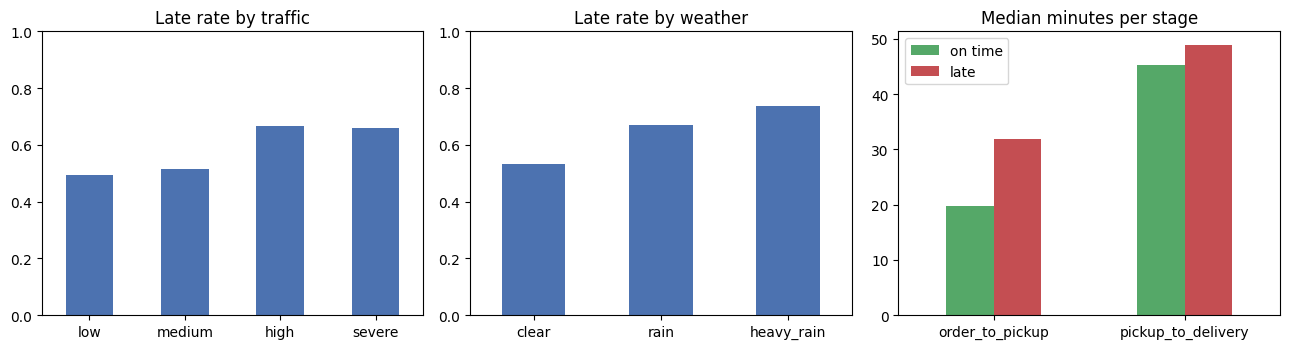

In [9]:
# Where in the order does the time go? Split each order into two stages.
delivered["order_to_pickup"] = (delivered.pickup_at - delivered.created_at).dt.total_seconds() / 60
delivered["pickup_to_delivery"] = (delivered.actual_delivery_at - delivered.pickup_at).dt.total_seconds() / 60
stages = delivered.groupby("late")[["order_to_pickup", "pickup_to_delivery"]].median().round(1)
stages.index = ["on time", "late"]
display(stages)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
late_table("traffic").reindex(["low", "medium", "high", "severe"])["late_rate"].plot(kind="bar", ax=axes[0], color="#4c72b0")
axes[0].set_title("Late rate by traffic"); axes[0].set_ylim(0, 1)
late_table("weather_bucket").reindex(["clear", "rain", "heavy_rain"])["late_rate"].plot(kind="bar", ax=axes[1], color="#4c72b0")
axes[1].set_title("Late rate by weather"); axes[1].set_ylim(0, 1)
stages.T.plot(kind="bar", ax=axes[2], color=["#55a868", "#c44e52"])
axes[2].set_title("Median minutes per stage")
for ax in axes: ax.tick_params(axis="x", rotation=0); ax.set_xlabel("")
plt.tight_layout(); plt.show()

### Challenge 2 answer

| Comparison | What the data shows |
|---|---|
| Traffic | High/severe traffic orders are late ~66% of the time vs ~49% in low traffic. There is an association. |
| Weather | Heavy rain 74% late, rain 67%, clear 53%. This is also associated, possibly more strongly than traffic. |
| Distance | No clear pattern, and half the rows are the 18.00 km placeholder, so this dimension is unreliable. |
| Stage split | Late orders wait a median **32 min** from order to pickup vs **20 min** for on-time orders. The drive itself is only a few minutes longer (49 vs 45). |

- **Hypothesis supported by evidence:** most of the delay builds up **before pickup** (restaurant prep or the
  handoff to the driver), not on the road. Traffic makes things worse, but it doesn't explain the gap on its own.
- **Alternative I can't rule out:** the wait before pickup could be the driver arriving late at the restaurant
  rather than the kitchen being slow. There is no "driver arrived at restaurant" event (see Challenge 5), so I can't
  separate the two.
- These are **associations, not causes**. Rain, traffic and busy restaurants tend to happen at the same times.

# Challenge 3 — Customer Support disagrees

Use `support_tickets.csv`.

### Questions
1. What are customers actually complaining about?
2. Which complaint types are most common?
3. Are ticket IDs unique?
4. Does the customer story match the operational story?
5. What can tickets tell you that timestamps cannot?

### Required output
A short **system view vs customer view** comparison.

In [10]:
display(tickets.head())

print("Complaint categories:")
display(tickets["category"].value_counts())

print("Duplicate ticket IDs:")
print(tickets["ticket_id"].duplicated().sum())

# Join syntax if useful:
# merged = tickets.merge(order_analysis, on="order_id", how="left")

# TODO: compare support evidence with delivery analysis

,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


Complaint categories:


category
late_delivery        38
eta_changed          37
restaurant_delay     37
ready_but_waiting    33
status_mismatch      29
driver_not_moving    25
Late Delivery         1
late_delivery         1
ETA issue             1
Name: count, dtype: int64

Duplicate ticket IDs:
1


In [11]:
print("Exact duplicate rows:", tickets.duplicated().sum())
print("Tickets with no order_id:", tickets["order_id"].isna().sum())

t = tickets.drop_duplicates("ticket_id").copy()
t["category_clean"] = t["category"].str.strip().str.lower().replace({"late delivery": "late_delivery"})
print("Category variants that are only spelling differences:",
      sorted(set(t.category) - set(t.category_clean)))

theme = {"restaurant_delay": "restaurant / pickup handoff", "ready_but_waiting": "restaurant / pickup handoff",
         "status_mismatch": "restaurant / pickup handoff", "eta_changed": "ETA communication",
         "eta issue": "ETA communication", "late_delivery": "late (no detail)", "driver_not_moving": "driver"}
t["theme"] = t["category_clean"].map(theme)

joined = t.merge(delivered[["order_id", "late", "delay_min"]], on="order_id", how="left")
view = (joined.groupby("theme")
        .agg(tickets=("ticket_id", "count"), share_late=("late", "mean"), median_delay_min=("delay_min", "median"))
        .sort_values("tickets", ascending=False).round(2))
view["share_of_tickets"] = (view.tickets / view.tickets.sum()).round(2)
view

Exact duplicate rows: 1
Tickets with no order_id: 3
Category variants that are only spelling differences: ['ETA issue', 'Late Delivery', 'late_delivery ']


,tickets,share_late,median_delay_min,share_of_tickets
theme,,,,
restaurant / pickup handoff,99,0.857143,11.87,0.49
late (no detail),39,0.868421,14.78,0.19
ETA communication,38,0.805556,7.65,0.19
driver,25,0.68,10.37,0.12


### Challenge 3 answer: system view vs customer view

| | System view (timestamps) | Customer view (tickets) |
|---|---|---|
| What's wrong? | 56% of orders miss the ETA, mostly by a few minutes | Customers complain about specific moments in the order |
| Main theme | Traffic and rain are associated with lateness | **About half of tickets are about the restaurant/pickup handoff**: food "still preparing", "ready but no rider", app and restaurant disagreeing |
| Second theme | – | The ETA keeps changing (communication, not just speed) |

- **Tickets are nearly unique:** one ticket (`T00013`) is an exact duplicate, and 3 tickets have no `order_id`.
  Three categories are only spelling variants (`Late Delivery`, `late_delivery ` with a space, `ETA issue`).
- The customer story **agrees with the stage split in Challenge 2**: the problem sits around pickup, not only on the road.
- **What tickets tell us that timestamps can't:** *why* the customer is unhappy. For example "food is ready but no
  rider picked it up" points to a handoff problem that no timestamp in the orders table records.

# Challenge 4 — Dispatch API: prove you retrieved everything

Your task:
1. start the API,
2. inspect one response,
3. retrieve **all** records,
4. handle pagination,
5. handle retryable failures,
6. save every successful raw page,
7. prove ingestion completeness.

A successful HTTP `200` on one page does **not** prove the job succeeded.

In [12]:
# Start the mock API
api_script = BASE / "api" / "mock_dispatch_api.py"

api_proc = subprocess.Popen(
    [sys.executable, str(api_script)],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(2)
health = requests.get("http://127.0.0.1:8000/health", timeout=10)
print(health.status_code, health.json())

200 {'service': 'flasheats-dispatch-api', 'status': 'ok'}


In [13]:
# Basic API syntax
API_URL = "http://127.0.0.1:8000/dispatch/orders"

response = requests.get(
    API_URL,
    params={"page": 1, "page_size": 50},
    timeout=10
)

print("HTTP:", response.status_code)

if response.ok:
    payload = response.json()
    print("Keys:", payload.keys())
    print("Records on page:", len(payload["data"]))
    print("Has more:", payload["has_more"])
    print("Reported total:", payload["total_records"])

HTTP: 200
Keys: dict_keys(['data', 'has_more', 'page', 'page_size', 'total_records'])
Records on page: 50
Has more: True
Reported total: 1600


In [14]:
RAW_DIR = BASE / "student_output" / "raw_dispatch"
RAW_DIR.mkdir(parents=True, exist_ok=True)
for old in RAW_DIR.glob("page_*.json"):
    old.unlink()          # start clean so the folder only holds this run's pages

RETRYABLE = {429, 500, 502, 503, 504}

def fetch_all_dispatch_orders(page_size=50, max_retries=4):
    """Fetch every page, retry 429/5xx with backoff, save each good page, then prove completeness."""
    records, attempts_log, page, reported_total = [], [], 1, None
    while True:
        for attempt in range(1, max_retries + 1):
            resp = requests.get(API_URL, params={"page": page, "page_size": page_size}, timeout=10)
            attempts_log.append({"page": page, "attempt": attempt, "status": resp.status_code})
            if resp.status_code in RETRYABLE:
                wait = float(resp.json().get("retry_after_seconds", 0.5 * 2 ** (attempt - 1)))
                time.sleep(wait)
                continue
            resp.raise_for_status()          # any other error is not retryable: stop loudly
            break
        else:
            raise RuntimeError(f"Page {page} still failing after {max_retries} attempts")

        payload = resp.json()
        (RAW_DIR / f"page_{page:03d}.json").write_text(json.dumps(payload, indent=1))   # raw page, unchanged
        records.extend(payload["data"])
        reported_total = payload["total_records"]
        if not payload["has_more"]:
            break
        page += 1

    ids = [r["order_id"] for r in records]
    checks = {
        "pages fetched": page,
        "raw pages saved": len(list(RAW_DIR.glob("page_*.json"))),
        "records retrieved": len(records),
        "API total_records": reported_total,
        "unique order_ids": len(set(ids)),
    }
    if len(records) != reported_total or len(set(ids)) != len(records):
        raise RuntimeError(f"Ingestion incomplete, refusing to report success: {checks}")
    return records, pd.DataFrame(attempts_log), checks

dispatch_records, attempts, checks = fetch_all_dispatch_orders()
print("Completeness checks:", checks)
print("Pages that needed a retry:")
display(attempts[attempts.status != 200])

Completeness checks: {'pages fetched': 32, 'raw pages saved': 32, 'records retrieved': 1600, 'API total_records': 1600, 'unique order_ids': 1600}
Pages that needed a retry:


,page,attempt,status
2,3,1,500
5,5,1,429


In [15]:
dispatch = pd.DataFrame(dispatch_records)
for c in ["assigned_at", "reassigned_at", "estimated_pickup_at", "current_delivery_eta"]:
    dispatch[c] = pd.to_datetime(dispatch[c], format="mixed", errors="coerce")

print("Dispatch orders missing from the orders table:", (~dispatch.order_id.isin(orders.order_id)).sum())
print("Orders missing from dispatch:", (~orders.order_id.isin(dispatch.order_id)).sum())
print("Orders that were reassigned to another driver:", dispatch.reassigned_at.notna().sum())

d = delivered.merge(dispatch, on="order_id", how="left", suffixes=("", "_dispatch"))
d["minutes_to_assign"] = (d.assigned_at - d.created_at).dt.total_seconds() / 60
d["pickup_vs_estimate"] = (d.pickup_at - d.estimated_pickup_at).dt.total_seconds() / 60
stage = d.groupby("late")[["minutes_to_assign", "pickup_vs_estimate"]].median().round(1)
stage.index = ["on time", "late"]
stage

Dispatch orders missing from the orders table: 0
Orders missing from dispatch: 0
Orders that were reassigned to another driver: 95


,minutes_to_assign,pickup_vs_estimate
on time,2.3,1.8
late,2.3,13.9


### Challenge 4 answer

- The first request to page 3 returned **HTTP 500** and the first request to page 5 returned **HTTP 429**. Both
  succeeded on retry. A loop that stopped at the first error, or ignored it, would have silently lost 100 records.
- **Completeness is proven, not assumed:** 32 pages, 1,600 records, matching the API's `total_records`, with 1,600 unique
  `order_id`s. Every raw page is saved unchanged in `student_output/raw_dispatch/`. If any check fails, the function
  raises an error instead of returning partial data.
- Dispatch adds something the orders table can't show: **95 orders were reassigned** to a different driver.
- It also supports the Challenge 2 hypothesis. Drivers are assigned in about 2 minutes whether the order ends up late
  or not, but **late orders are picked up about 14 minutes after dispatch's estimated pickup time, vs about 2 minutes for
  on-time orders**. The delay is at pickup, not at assignment.

# Challenge 5 — Can we attribute the delay?

Inspect `driver_events.json`.

Look for:
- assignment,
- GPS pings,
- pickup,
- delivery.

Then answer:

> **Can we reliably tell when the driver arrived at the restaurant?**

Be precise about:
- **Observed** = directly stored.
- **Inferred** = estimated from another signal, such as GPS.

### Required output

| Event / fact | Observed? | Source | Reliability concern |
|---|---|---|---|
| Driver assigned |  |  |  |
| Driver at restaurant |  |  |  |
| Picked up |  |  |  |
| Delivered |  |  |  |

In [16]:
first_driver = driver_events[0]
print("Driver:", first_driver["driver_id"])
display(pd.DataFrame(first_driver["events"]).head(15))

# Flatten nested JSON
flat_events = []
for driver in driver_events:
    for event in driver["events"]:
        flat_events.append({"driver_id": driver["driver_id"], **event})

driver_events_df = pd.DataFrame(flat_events)
display(driver_events_df.head())

print("Event types:")
display(driver_events_df["type"].value_counts())

# TODO: can you find an explicit driver_arrived_at_restaurant event?

Driver: D001


,order_id,type,timestamp,lat,lon
0,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558
5,O00162,picked_up,2026-08-26T18:27:32.131791,NaN,NaN
6,O00162,delivered,2026-08-26T19:21:12.950887,NaN,NaN
7,O00180,assigned,2026-08-08T18:05:08.439625,NaN,NaN
8,O00180,gps_ping,2026-08-08T18:28:19.378257,13.073469,77.716653
9,O00180,gps_ping,2026-08-08T18:51:30.316889,13.071031,77.659475


,driver_id,order_id,type,timestamp,lat,lon
0,D001,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,D001,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,D001,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,D001,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,D001,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558


Event types:


type
gps_ping     5371
assigned     1600
picked_up    1532
delivered    1532
Name: count, dtype: int64

In [17]:
driver_events_df["ts"] = pd.to_datetime(driver_events_df["timestamp"], format="mixed")
print("Explicit driver_arrived_at_restaurant event present:",
      driver_events_df["type"].str.contains("arriv", case=False).any())

pings = driver_events_df[driver_events_df.type == "gps_ping"].sort_values(["order_id", "ts"])
gap = pings.groupby("order_id")["ts"].diff().dt.total_seconds() / 60
print(f"GPS ping interval: median {gap.median():.1f} min, max {gap.max():.0f} min")

ev = driver_events_df.pivot_table(index="order_id", columns="type", values="ts", aggfunc="first")
cmp = orders.set_index("order_id")[["status", "pickup_at", "actual_delivery_at"]].join(ev[["picked_up", "delivered"]])
missing = cmp[(cmp.status == "delivered") & cmp.actual_delivery_at.isna()]
print("Delivered orders missing actual_delivery_at in orders:", len(missing),
      "| of those, driver app has a delivered time:", missing["delivered"].notna().sum())

pickup_gap = (cmp.picked_up - cmp.pickup_at).dt.total_seconds() / 60
print("Orders where the two pickup times disagree:")
display(pickup_gap[pickup_gap.abs() > 1].round(1).rename("driver_app_minus_orders_min").to_frame())

Explicit driver_arrived_at_restaurant event present: False
GPS ping interval: median 13.4 min, max 41 min
Delivered orders missing actual_delivery_at in orders: 37 | of those, driver app has a delivered time: 37
Orders where the two pickup times disagree:


,driver_app_minus_orders_min
order_id,
O00051,-58.9
O00052,-56.7
O00053,-43.5
O00054,-61.3
O00055,-48.0


### Challenge 5 answer

| Event / fact | Observed? | Source | Reliability concern |
|---|---|---|---|
| Driver assigned | Yes | `driver_events` `assigned`, Dispatch `assigned_at` | The driver app only shows the final driver; reassignments (95) are only in Dispatch |
| Driver at restaurant | **No, inferred only** | GPS pings | No arrival event exists. Pings come every ~13 min, so arrival could only be estimated to within about ±13 min |
| Picked up | Yes | `driver_events` `picked_up`, `orders.pickup_at` | The two agree except for 5 orders, where `orders.pickup_at` is ~50 min later. These are the same 5 "delivered before pickup" rows, so the orders table is the one that's wrong |
| Delivered | Yes | `driver_events` `delivered`, `orders.actual_delivery_at` | The driver app has a delivery time for all 37 orders missing it in the orders table, so they can be recovered |

**We cannot reliably tell when the driver arrived at the restaurant.** That is exactly the fact needed to split
"kitchen was slow" from "driver was late", so it limits any root-cause claim.

# Final FDE synthesis — one slide only

Your final slide must answer:

1. **Problem size** — how large is the late-delivery problem?
2. **Evidence** — what appears related to delay?
3. **Trusted sources** — which sources do you trust for which facts?
4. **Uncertainty** — what can you not determine confidently?
5. **Instrumentation recommendation** — what should FlashEats capture/fix next?
6. **Decision** — would you build the AI delay predictor now? Why or why not?

Use language such as:
- “The data shows…”
- “This is associated with…”
- “We cannot determine…”
- “We would need X before concluding Y…”

### My one-slide synthesis

**1. Problem size.** The data shows 56.4% of delivered orders miss the promised ETA, but only 23.3% miss it by more
than 10 minutes. The median late order is 8 minutes late.

**2. Evidence.** Lateness is associated with rain and heavy traffic, but the biggest difference is **before
pickup**: late orders wait 32 min vs 20 min to be picked up, and are picked up ~14 min behind dispatch's own
estimate. About half of support tickets describe the same handoff problem.

**3. Trusted sources.** Orders table for promise and outcome (after de-duplication). Dispatch API for assignment and
reassignment. Driver app for pickup and delivery times (it fills 37 gaps and corrects 5 errors). Tickets and restaurant
status are context only.

**4. Uncertainty.** We cannot determine whether the pre-pickup wait is the kitchen or the driver. There is no arrival
event, GPS is too sparse, and distance is a placeholder for half the orders.

**5. Instrumentation.** Capture a *driver arrived at restaurant* event (geofence) and a system-generated *food
ready* time from the restaurant. Fix the distance field and the duplicate and timestamp errors at source.

**6. Decision.** **I would not build the AI delay predictor yet.** It would be learning from a target whose
definition is disputed and from inputs that are missing the most important step. The evidence already points to an
operational fix at pickup that doesn't need ML. We would need the arrival and ready events before a model could explain
anything useful.

In [18]:
# Optional cleanup
try:
    con.close()
except:
    pass

try:
    api_proc.terminate()
except:
    pass

print("Session cleanup complete.")

Session cleanup complete.
